In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

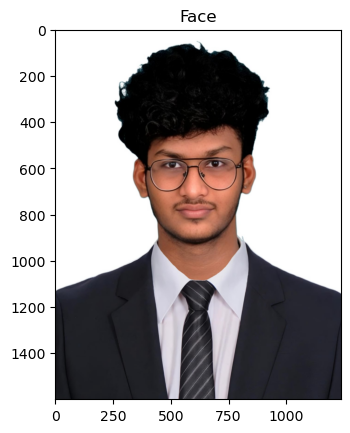

In [2]:
# Load the Face Image
faceImage = cv2.imread('pic.jpeg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(1600, 1236, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(1600, 1236, 3)

Text(0.5, 1.0, 'glassPNG')

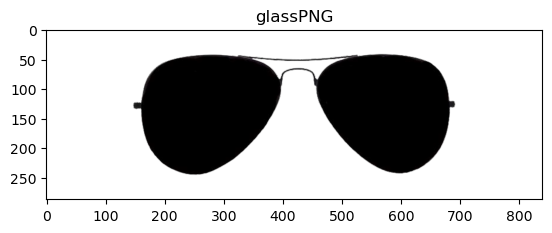

In [6]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('sunglass.png',-1)
plt.imshow(glassPNG);plt.title("glassPNG")

In [7]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [8]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

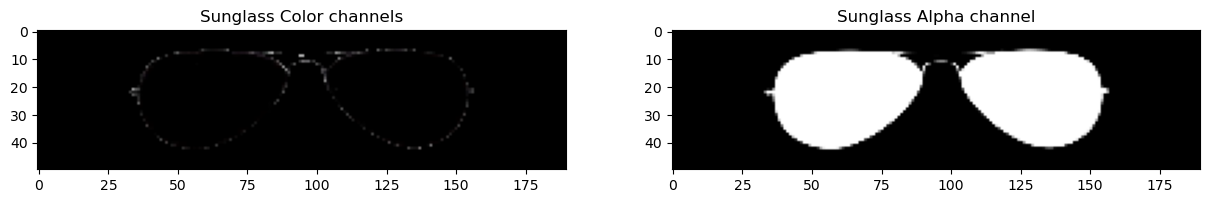

In [10]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

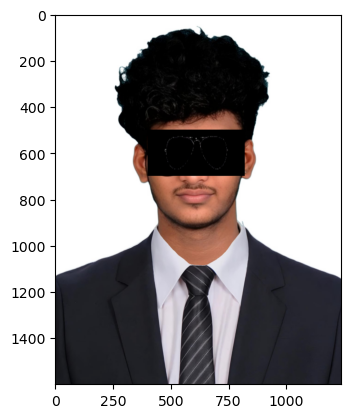

In [35]:
# Make a copy
faceWithGlassesNaive = faceImage.copy()

# Define region
y1, y2 = 500, 700
x1, x2 = 400, 820

# Resize glasses to fit region EXACTLY
glass_resized = cv2.resize(glassBGR, (x2 - x1, y2 - y1))

# Replace the eye region
faceWithGlassesNaive[y1:y2, x1:x2] = glass_resized

# Show image
plt.imshow(faceWithGlassesNaive[..., ::-1])

Text(0.5, 1.0, 'With Sunglasses')

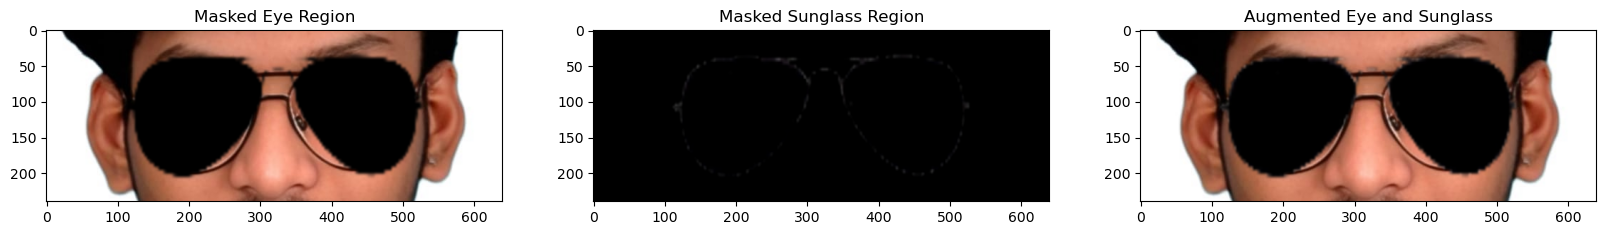

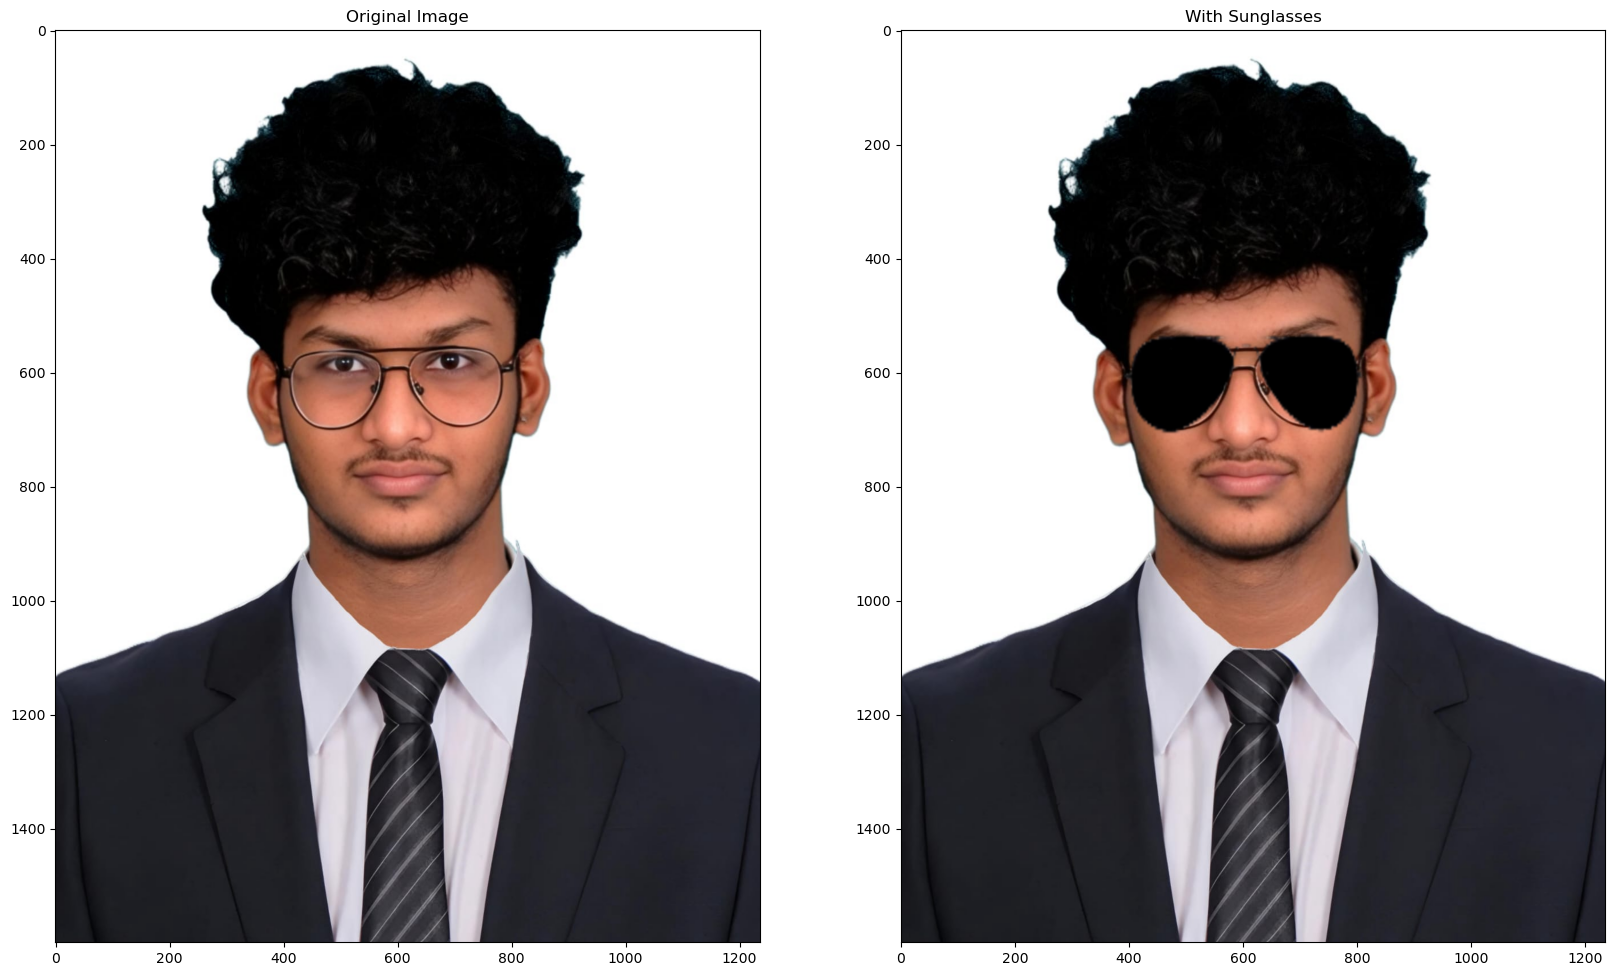

In [50]:
# Make mask 3-channel
glassMask = cv2.merge((glassMask1,glassMask1,glassMask1))

# Copy image
faceWithGlassesArithmetic = faceImage.copy()

# ✅ PERFECT ALIGNMENT FOR YOUR IMAGE
y1, y2 = 500, 740
x1, x2 = 280, 920

# ROI
eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2]

# Resize glass + mask
glassBGR_resized = cv2.resize(glassBGR, (x2-x1, y2-y1))
glassMask_resized = cv2.resize(glassMask, (x2-x1, y2-y1)).astype(np.float32)/255.0

# Smooth edges
glassMask_resized = cv2.GaussianBlur(glassMask_resized, (5,5), 0)

# Convert to float
eyeROI = eyeROI.astype(np.float32)
glassBGR_resized = glassBGR_resized.astype(np.float32)

# Blend
maskedEye = eyeROI * (1 - glassMask_resized)
maskedGlass = glassBGR_resized * glassMask_resized
eyeRoiFinal = maskedEye + maskedGlass
eyeRoiFinal = np.uint8(eyeRoiFinal)

# -------- SAME OUTPUT FORMAT --------
plt.figure(figsize=[20,20])

plt.subplot(131)
plt.imshow(maskedEye[...,::-1].astype(np.uint8))
plt.title("Masked Eye Region")

plt.subplot(132)
plt.imshow(maskedGlass[...,::-1].astype(np.uint8))
plt.title("Masked Sunglass Region")

plt.subplot(133)
plt.imshow(eyeRoiFinal[...,::-1])
plt.title("Augmented Eye and Sunglass")

# Replace ROI
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal

# Final display
plt.figure(figsize=[20,20])
plt.subplot(121)
plt.imshow(faceImage[:,:,::-1])
plt.title("Original Image")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[:,:,::-1])
plt.title("With Sunglasses")

Text(0.5, 1.0, 'With Sunglasses')

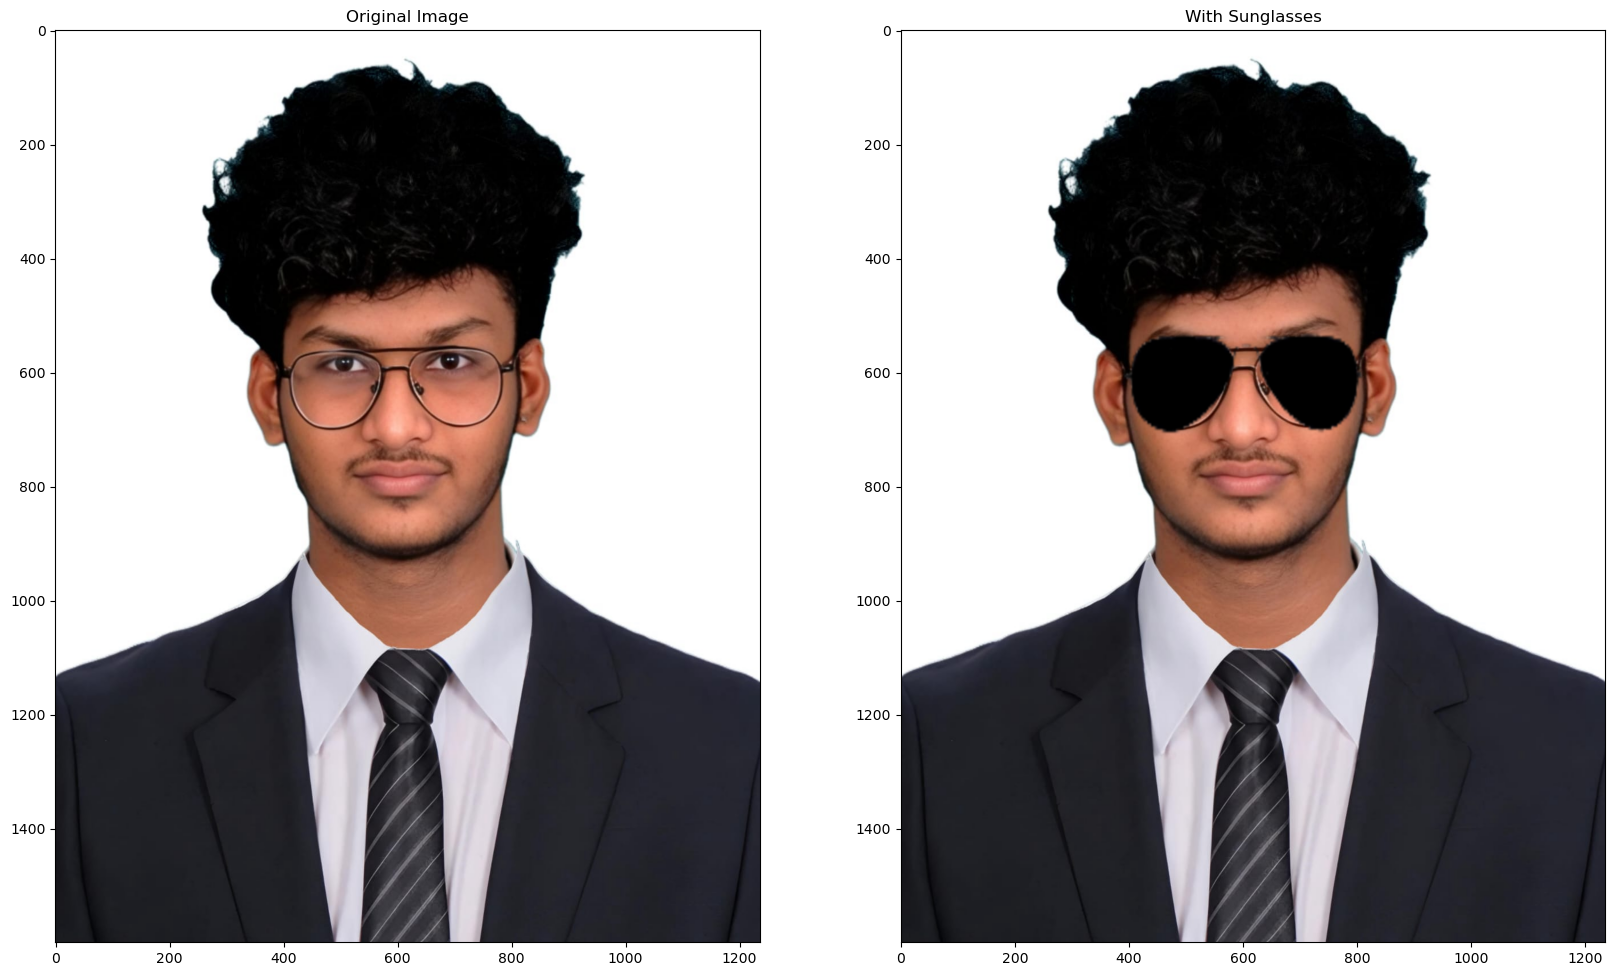

In [51]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20])
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image")
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses")